# BÀI TẬP: TITANIC
**Nguồn:** kaggle.com/c/titanic (891 dòng)


In [14]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
# TODO
print('kích thước dữ liệu:', df.shape)
print()
print('các cột dữ liệu:', df.columns)
print()
print('kiểu dữ liệu các cột:', df.dtypes)
print()
df.info()

kích thước dữ liệu: (891, 15)

các cột dữ liệu: Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

kiểu dữ liệu các cột: survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int

## A.2. Missing values & Duplicate data

In [3]:
# TODO
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing>0] if missing.sum()>0 else "Không có cột nào thiếu dữ liệu.")
print()
print("tổng số dòng bị trùng lặp hoàn toàn:", df.duplicated().sum())

Missing values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

tổng số dòng bị trùng lặp hoàn toàn: 107


## A.3. Invalid values

In [4]:
# TODO
print("age < 0:", (df['age'] < 0).sum())
print("fare < 0:", (df['fare'] < 0).sum())
print("sibsp < 0:", (df['sibsp'] < 0).sum())
print("parch < 0:", (df['parch'] < 0).sum())
print("survived ngoài [0, 1]:", ((df['survived'] < 0) | (df['survived'] > 1)).sum())
print("pclass ngoài [1, 2, 3]:", (~df['pclass'].isin([1, 2, 3])).sum())
print()
print("=> Dữ liệu khá sạch: không có giá trị vô lý (âm) ở các cột tuổi, giá vé và số người thân.")

age < 0: 0
fare < 0: 0
sibsp < 0: 0
parch < 0: 0
survived ngoài [0, 1]: 0
pclass ngoài [1, 2, 3]: 0

=> Dữ liệu khá sạch: không có giá trị vô lý (âm) ở các cột tuổi, giá vé và số người thân.


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [5]:
# TODO
df['family_size'] = df['sibsp'] + df['parch'] + 1

---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [6]:
# TODO
for col in ['age', 'fare']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")
print()
print("Mode class:", df['class'].mode()[0])

age: Mean=29.70, Median=28.00, Mode=24.00
fare: Mean=32.20, Median=14.45, Mode=8.05

Mode class: Third


## Group 2 — Dispersion

In [7]:
# TODO
for col in ['age', 'fare']:
    s = df[col]
    range_ = s.max() - s.min()
    std_ = s.std()
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    cv = std_ / s.mean()
    
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

--- age ---
Range=79.58, Std=14.53, IQR=17.88, CV=0.49
--- fare ---
Range=512.33, Std=49.69, IQR=23.09, CV=1.54


## Group 3 — Location and Shape

--- age ---
P25=20.12, P50=28.00, P75=38.00
Skewness=0.39, Kurtosis=0.17
--- fare ---
P25=7.91, P50=14.45, P75=31.00
Skewness=4.78, Kurtosis=33.20


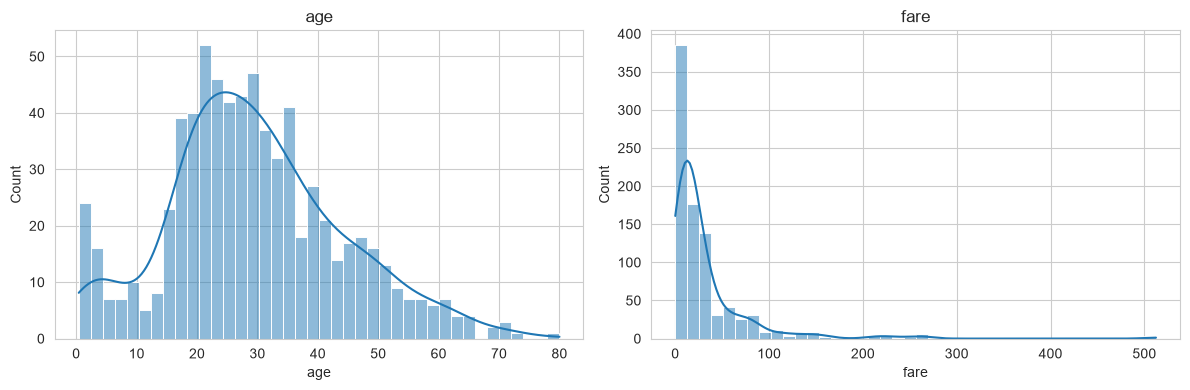

Nhận xét:
- Cột 'age': Phân phối khá đối xứng. Đa số hành khách từ 20-30 tuổi, kèm theo một nhóm nhỏ trẻ em.
- Cột 'fare': Lệch phải rất mạnh và nhọn (Kurtosis cao). Đại đa số mua vé giá rẻ, chỉ có số ít vé VIP cực đắt (outliers).


In [8]:
# TODO
for col in ['age', 'fare']:
    s = df[col].dropna()
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['age'], bins=40, kde=True, ax=axes[0]); axes[0].set_title('age')
sns.histplot(df['fare'], bins=40, kde=True, ax=axes[1]); axes[1].set_title('fare')
plt.tight_layout(); plt.show()

print("Nhận xét:")
print("- Cột 'age': Phân phối khá đối xứng. Đa số hành khách từ 20-30 tuổi, kèm theo một nhóm nhỏ trẻ em.")
print("- Cột 'fare': Lệch phải rất mạnh và nhọn (Kurtosis cao). Đại đa số mua vé giá rẻ, chỉ có số ít vé VIP cực đắt (outliers).")

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

class
First     62.96
Second    47.28
Third     24.24
Name: survived, dtype: float64

=> Hạng vé First có tỷ lệ sống sót cao nhất (62.96%), chênh lệch 38.73% so với hạng thấp nhất.


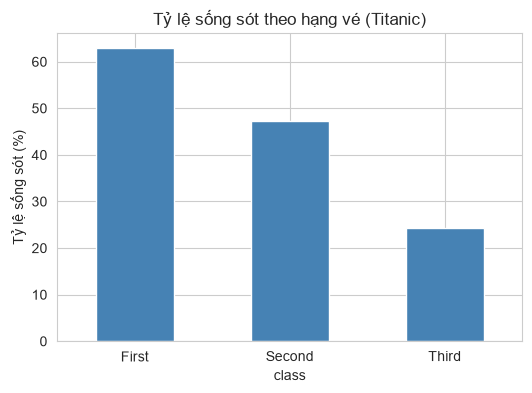

In [9]:
# TODO
survival_by_class = df.groupby('class')['survived'].mean().sort_values(ascending=False) * 100
highest_class = survival_by_class.index[0]
highest_rate = survival_by_class.iloc[0]
lowest_rate = survival_by_class.iloc[-1]
diff = highest_rate - lowest_rate
print(survival_by_class.round(2))
print(f"\n=> Hạng vé {highest_class} có tỷ lệ sống sót cao nhất ({highest_rate:.2f}%), chênh lệch {diff:.2f}% so với hạng thấp nhất.")

fig, ax = plt.subplots(figsize=(6, 4))
survival_by_class.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Tỷ lệ sống sót theo hạng vé (Titanic)')
ax.set_ylabel('Tỷ lệ sống sót (%)')
plt.xticks(rotation=0)
plt.show()

**Insight:** Tỷ lệ sống sót có sự phân hóa cực kỳ rõ rệt theo hạng vé (Hạng Nhất sống sót cao nhất, giảm dần đến Hạng Ba). Điều này phản ánh sự bất bình đẳng xã hội: những hành khách giàu có ở hạng vé cao được ưu tiên cứu viện hoặc có vị trí phòng ở các boong trên cao, gần thuyền cứu sinh hơn nên cơ hội thoát nạn lớn hơn hẳn.

## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [10]:
# TODO
surv_by_sex = df.groupby('sex')['survived'].mean() * 100
surv_by_class = df.groupby('class')['survived'].mean() * 100

print("--- Tỷ lệ sống sót theo Giới tính ---")
print(surv_by_sex.round(2))
print(f"-> Chênh lệch giới tính: {surv_by_sex.max() - surv_by_sex.min():.2f}%\n")

print("--- Tỷ lệ sống sót theo Hạng vé ---")
print(surv_by_class.round(2))
print(f"-> Chênh lệch hạng vé: {surv_by_class.max() - surv_by_class.min():.2f}%")

--- Tỷ lệ sống sót theo Giới tính ---
sex
female    74.20
male      18.89
Name: survived, dtype: float64
-> Chênh lệch giới tính: 55.31%

--- Tỷ lệ sống sót theo Hạng vé ---
class
First     62.96
Second    47.28
Third     24.24
Name: survived, dtype: float64
-> Chênh lệch hạng vé: 38.73%


**Insight:** Giới tính ảnh hưởng mạnh hơn hẳn hạng vé. Tỷ lệ sống sót của nữ cao hơn nam tới hơn 55%, trong khi chênh lệch giữa hạng vé cao nhất và thấp nhất chỉ khoảng 38%. Điều này cho thấy quy tắc "Ưu tiên phụ nữ và trẻ em" được thực thi rất nghiêm ngặt.

## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [11]:
# TODO
fare_by_survival = df.groupby('survived')['fare'].mean()

print("Giá vé trung bình:")
print(f"- Không sống sót (0): {fare_by_survival[0]:.2f}")
print(f"- Sống sót (1): {fare_by_survival[1]:.2f}")

Giá vé trung bình:
- Không sống sót (0): 22.12
- Sống sót (1): 48.40


**Insight:** Có. Giá vé trung bình của nhóm sống sót cao gấp đôi so với nhóm tử nạn. Khách trả nhiều tiền (mua vé hạng sang) rõ ràng có lợi thế lớn hơn trong việc tiếp cận xuồng cứu sinh.

## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [12]:
# TODO
surv_by_family = df.groupby('family_size')['survived'].mean() * 100
print(surv_by_family.round(2))

family_size
1     30.35
2     55.28
3     57.84
4     72.41
5     20.00
6     13.64
7     33.33
8      0.00
11     0.00
Name: survived, dtype: float64


**Insight:** Gia đình có ảnh hưởng lớn. Đi một mình (0) có tỷ lệ sống thấp (chỉ khoảng 30%). Đi cùng gia đình nhỏ (1-3 người thân) giúp tỷ lệ sống sót tăng lên cao nhất (hơn 50-70%). Tuy nhiên, gia đình quá đông (từ 4 người trở lên) lại làm giảm mạnh cơ hội sống, có thể do việc tập hợp đông người trong lúc hoảng loạn rất mất thời gian.

## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [13]:
# TODO
surv_by_town = df.groupby('embark_town')['survived'].mean() * 100
print(surv_by_town.sort_values(ascending=False).round(2))

embark_town
Cherbourg      55.36
Queenstown     38.96
Southampton    33.70
Name: survived, dtype: float64


**Insight:** Khách lên tàu ở cảng Cherbourg có tỷ lệ sống sót cao nhất (khoảng 55%). Điều này nhiều khả năng không phải do vị trí địa lý mang lại may mắn, mà là vì đa số hành khách mua vé Hạng Nhất đắt tiền bước lên tàu từ cảng này.

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

Phân tích dữ liệu Titanic cho thấy giới tính là yếu tố quyết định sinh tử lớn nhất, với tỷ lệ sống sót của phụ nữ áp đảo hoàn toàn nam giới do quy tắc ưu tiên cứu hộ. Bên cạnh đó, đặc quyền giai cấp cũng thể hiện rõ nét khi nhóm hành khách giàu có mua vé Hạng Nhất có lợi thế thoát nạn vượt trội so với Hạng Ba. Ngoài ra, việc đi cùng một gia đình nhỏ (1-3 người) giúp hỗ trợ nhau tăng cơ hội sống, nhưng gia đình quá đông lại trở thành cản trở trong lúc hoảng loạn. Tóm lại, chân dung của một hành khách có xác suất sống sót cao nhất trên chuyến tàu định mệnh này là một phụ nữ thuộc tầng lớp thượng lưu và đi cùng một vài người thân.